# Real CA1 Phase-Locking Analysis

This notebook analyzes phase-locking of CA1 neurons to the inferred theta
oscillation, using the model results from the theta segmentation notebook.

## Goals

1. Compute spike-phase histograms using inferred theta phase
2. Perform Rayleigh tests for phase locking significance
3. Analyze phase preference distribution across neurons
4. Validate phase preferences against model-learned weights
5. Compare phase locking during theta-on vs theta-off states

## Setup

In [1]:
# Enable 64-bit precision for numerical stability
import jax

jax.config.update("jax_enable_x64", True)

In [2]:
# Imports
import pickle
import sys
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Add project root to path for imports
# Handle both running from notebooks/ directory and from project root
if Path.cwd().name == "notebooks":
    project_root = Path.cwd().parent
else:
    project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from state_space_practice.circular_stats import (
    circular_correlation,
    circular_mean,
    compute_phase_histogram,
    compute_preferred_phase,
    mean_resultant_length,
    rayleigh_test,
)

print(f"JAX version: {jax.__version__}")
print(f"Using device: {jax.devices()[0]}")

JAX version: 0.6.2
Using device: TFRT_CPU_0


## 1. Load Results

In [3]:
# Load theta segmentation results
data_path = project_root / "data"
results_path = data_path / "ca1_theta_results.pkl"

with open(results_path, "rb") as f:
    results = pickle.load(f)

theta_on_prob = results["theta_on_prob"]
inferred_amplitude = results["inferred_amplitude"]
inferred_phase = results["inferred_phase"]
inferred_states = results["inferred_states"]
time_subset = results["time_subset"]
spikes_subset = results["spikes_subset"]
behavioral_labels = results["behavioral_labels_subset"]
model_preferred_phases = results["preferred_phases"]
model_modulation_strength = results["modulation_strength"]

# Load preprocessed data for spike times
preprocessed_path = data_path / "ca1_preprocessed_250Hz.pkl"
with open(preprocessed_path, "rb") as f:
    preproc = pickle.load(f)

sampling_freq = preproc["sampling_freq"]
dt = preproc["dt"]

n_neurons = spikes_subset.shape[1]
n_time = len(theta_on_prob)

print("Data loaded!")
print(f"  Time points: {n_time:,}")
print(f"  Neurons: {n_neurons}")
print(f"  Duration: {n_time * dt:.1f} s")

Data loaded!
  Time points: 75,000
  Neurons: 107
  Duration: 300.0 s


## 2. Define Theta-On Mask

In [4]:
# Create mask for theta-on periods
# Use both the discrete state probability and amplitude threshold
theta_on_mask = (theta_on_prob > 0.5) & (inferred_amplitude > 0.1)

print("Theta-on period selection:")
print(f"  P(theta-on) > 0.5: {100 * np.mean(theta_on_prob > 0.5):.1f}%")
print(f"  Amplitude > 0.1: {100 * np.mean(inferred_amplitude > 0.1):.1f}%")
print(f"  Combined: {100 * np.mean(theta_on_mask):.1f}%")

# Also create running-only mask
running_mask = behavioral_labels == 1
theta_on_running = theta_on_mask & running_mask
print(f"  Theta-on AND running: {100 * np.mean(theta_on_running):.1f}%")

Theta-on period selection:
  P(theta-on) > 0.5: 99.6%
  Amplitude > 0.1: 99.1%
  Combined: 98.6%
  Theta-on AND running: 49.5%


## 3. Compute Phase-Locking for Each Neuron

In [5]:
# Convert binned spikes to spike times for each neuron
t_rel = time_subset - time_subset[0]

def get_spike_times_from_binned(binned_spikes, time_bins, neuron_idx):
    """Extract spike times from binned spike counts."""
    spike_counts = binned_spikes[:, neuron_idx]
    spike_times = []
    for t_idx in np.where(spike_counts > 0)[0]:
        # Add spike time for each spike in the bin
        for _ in range(spike_counts[t_idx]):
            spike_times.append(time_bins[t_idx])
    return np.array(spike_times)

In [6]:
# Compute phase-locking statistics for each neuron
print("Computing phase-locking statistics...")

phase_locking_results = []
for n in range(n_neurons):
    spike_times_n = get_spike_times_from_binned(spikes_subset, t_rel, n)

    if len(spike_times_n) < 10:
        # Skip neurons with too few spikes
        phase_locking_results.append({
            "preferred_phase": np.nan,
            "mrl": np.nan,
            "p_value": np.nan,
            "n_spikes": len(spike_times_n),
        })
        continue

    # Compute preferred phase during theta-on periods
    pref_phase, mrl, p_val = compute_preferred_phase(
        spike_times=spike_times_n,
        inferred_phase=np.array(inferred_phase),
        time_axis=t_rel,
        mask=theta_on_mask,
    )

    phase_locking_results.append({
        "preferred_phase": pref_phase,
        "mrl": mrl,
        "p_value": p_val,
        "n_spikes": len(spike_times_n),
    })

# Convert to arrays
empirical_preferred_phases = np.array([r["preferred_phase"] for r in phase_locking_results])
empirical_mrl = np.array([r["mrl"] for r in phase_locking_results])
empirical_p_values = np.array([r["p_value"] for r in phase_locking_results])
n_spikes_per_neuron = np.array([r["n_spikes"] for r in phase_locking_results])

print("Done!")

Computing phase-locking statistics...
Done!


In [7]:
# Summary statistics
valid_mask = ~np.isnan(empirical_mrl)
n_valid = np.sum(valid_mask)
n_significant = np.sum(empirical_p_values[valid_mask] < 0.05)

print("\nPhase-locking summary:")
print(f"  Valid neurons (>10 spikes): {n_valid}/{n_neurons}")
print(f"  Significantly phase-locked (p < 0.05): {n_significant} ({100*n_significant/n_valid:.1f}%)")
print(f"  Mean MRL: {np.nanmean(empirical_mrl):.3f}")
print(f"  Max MRL: {np.nanmax(empirical_mrl):.3f}")


Phase-locking summary:
  Valid neurons (>10 spikes): 92/107
  Significantly phase-locked (p < 0.05): 92 (100.0%)
  Mean MRL: 0.788
  Max MRL: 0.975


## 4. Visualize Phase-Locking Results

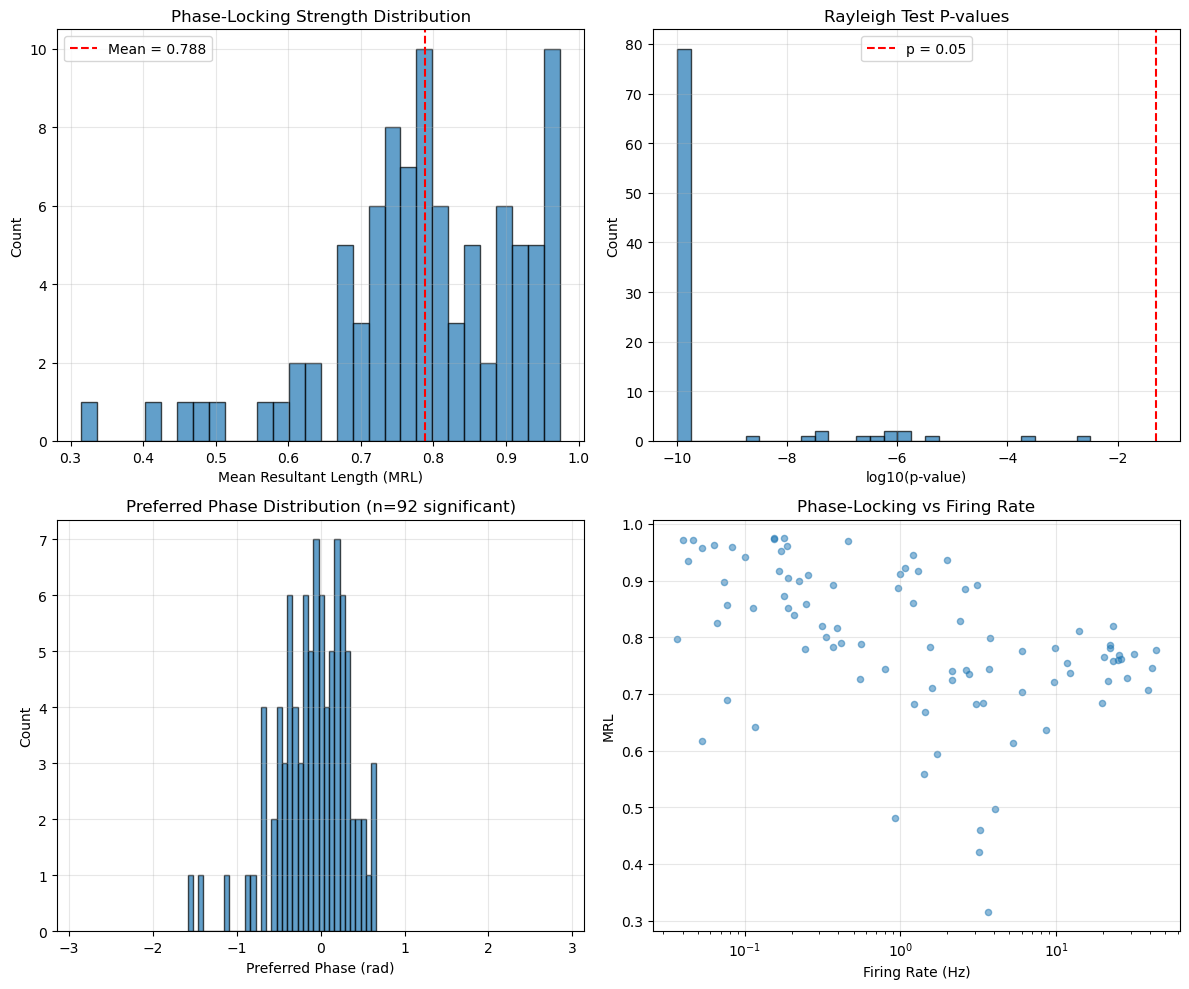

In [8]:
# Plot phase-locking statistics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# MRL distribution
ax = axes[0, 0]
ax.hist(empirical_mrl[valid_mask], bins=30, alpha=0.7, edgecolor="black")
ax.axvline(np.nanmean(empirical_mrl), color="red", linestyle="--", label=f"Mean = {np.nanmean(empirical_mrl):.3f}")
ax.set_xlabel("Mean Resultant Length (MRL)")
ax.set_ylabel("Count")
ax.set_title("Phase-Locking Strength Distribution")
ax.legend()
ax.grid(True, alpha=0.3)

# P-value distribution (log scale)
ax = axes[0, 1]
p_valid = empirical_p_values[valid_mask]
ax.hist(np.log10(p_valid + 1e-10), bins=30, alpha=0.7, edgecolor="black")
ax.axvline(np.log10(0.05), color="red", linestyle="--", label="p = 0.05")
ax.set_xlabel("log10(p-value)")
ax.set_ylabel("Count")
ax.set_title("Rayleigh Test P-values")
ax.legend()
ax.grid(True, alpha=0.3)

# Preferred phase distribution (only significant neurons)
ax = axes[1, 0]
sig_mask = valid_mask & (empirical_p_values < 0.05)
ax.hist(empirical_preferred_phases[sig_mask], bins=36, alpha=0.7, edgecolor="black")
ax.set_xlabel("Preferred Phase (rad)")
ax.set_ylabel("Count")
ax.set_title(f"Preferred Phase Distribution (n={np.sum(sig_mask)} significant)")
ax.set_xlim(-np.pi, np.pi)
ax.grid(True, alpha=0.3)

# MRL vs firing rate
ax = axes[1, 1]
firing_rates = n_spikes_per_neuron / (n_time * dt)
ax.scatter(firing_rates[valid_mask], empirical_mrl[valid_mask], alpha=0.5, s=20)
ax.set_xlabel("Firing Rate (Hz)")
ax.set_ylabel("MRL")
ax.set_title("Phase-Locking vs Firing Rate")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ca1_phase_locking_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Compare Empirical vs Model Preferred Phases

Circular correlation (model vs empirical phases): 0.958


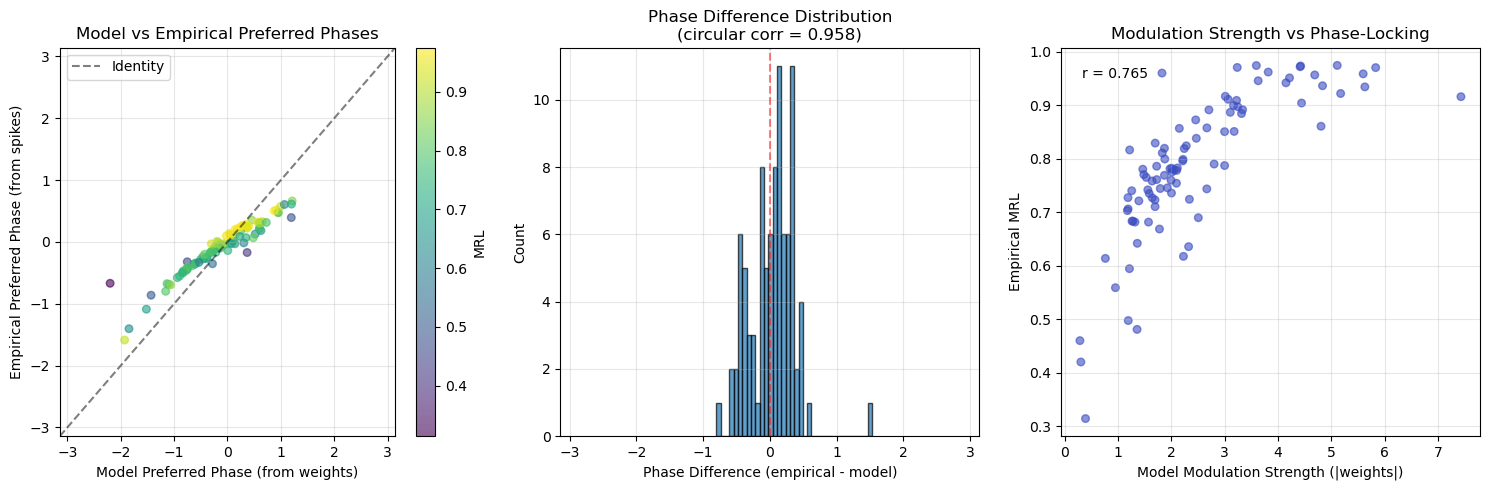

In [9]:
# Compare empirical preferred phases to model-learned spike weights
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatter plot: empirical vs model preferred phase
ax = axes[0]
mask = valid_mask & (empirical_p_values < 0.05)
ax.scatter(
    model_preferred_phases[mask],
    empirical_preferred_phases[mask],
    c=empirical_mrl[mask],
    cmap="viridis",
    alpha=0.6,
    s=30,
)
ax.plot([-np.pi, np.pi], [-np.pi, np.pi], "k--", alpha=0.5, label="Identity")
ax.set_xlabel("Model Preferred Phase (from weights)")
ax.set_ylabel("Empirical Preferred Phase (from spikes)")
ax.set_title("Model vs Empirical Preferred Phases")
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(ax.collections[0], ax=ax, label="MRL")

# Circular correlation
if np.sum(mask) > 5:
    circ_corr = circular_correlation(
        model_preferred_phases[mask],
        empirical_preferred_phases[mask]
    )
    print(f"Circular correlation (model vs empirical phases): {circ_corr:.3f}")
else:
    circ_corr = np.nan

# Phase difference distribution
ax = axes[1]
phase_diff = np.angle(np.exp(1j * (empirical_preferred_phases[mask] - model_preferred_phases[mask])))
ax.hist(phase_diff, bins=36, alpha=0.7, edgecolor="black")
ax.axvline(0, color="red", linestyle="--", alpha=0.5)
ax.set_xlabel("Phase Difference (empirical - model)")
ax.set_ylabel("Count")
ax.set_title(f"Phase Difference Distribution\n(circular corr = {circ_corr:.3f})")
ax.set_xlim(-np.pi, np.pi)
ax.grid(True, alpha=0.3)

# MRL vs modulation strength
ax = axes[2]
ax.scatter(
    model_modulation_strength[valid_mask],
    empirical_mrl[valid_mask],
    c=empirical_p_values[valid_mask] < 0.05,
    cmap="coolwarm",
    alpha=0.6,
    s=30,
)
ax.set_xlabel("Model Modulation Strength (|weights|)")
ax.set_ylabel("Empirical MRL")
ax.set_title("Modulation Strength vs Phase-Locking")
ax.grid(True, alpha=0.3)

# Correlation
mod_mrl_corr = pearsonr(
    model_modulation_strength[valid_mask],
    empirical_mrl[valid_mask]
)[0]
ax.text(0.05, 0.95, f"r = {mod_mrl_corr:.3f}", transform=ax.transAxes, fontsize=10,
        verticalalignment='top')

plt.tight_layout()
plt.savefig("ca1_phase_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Spike-Phase Histograms for Example Neurons

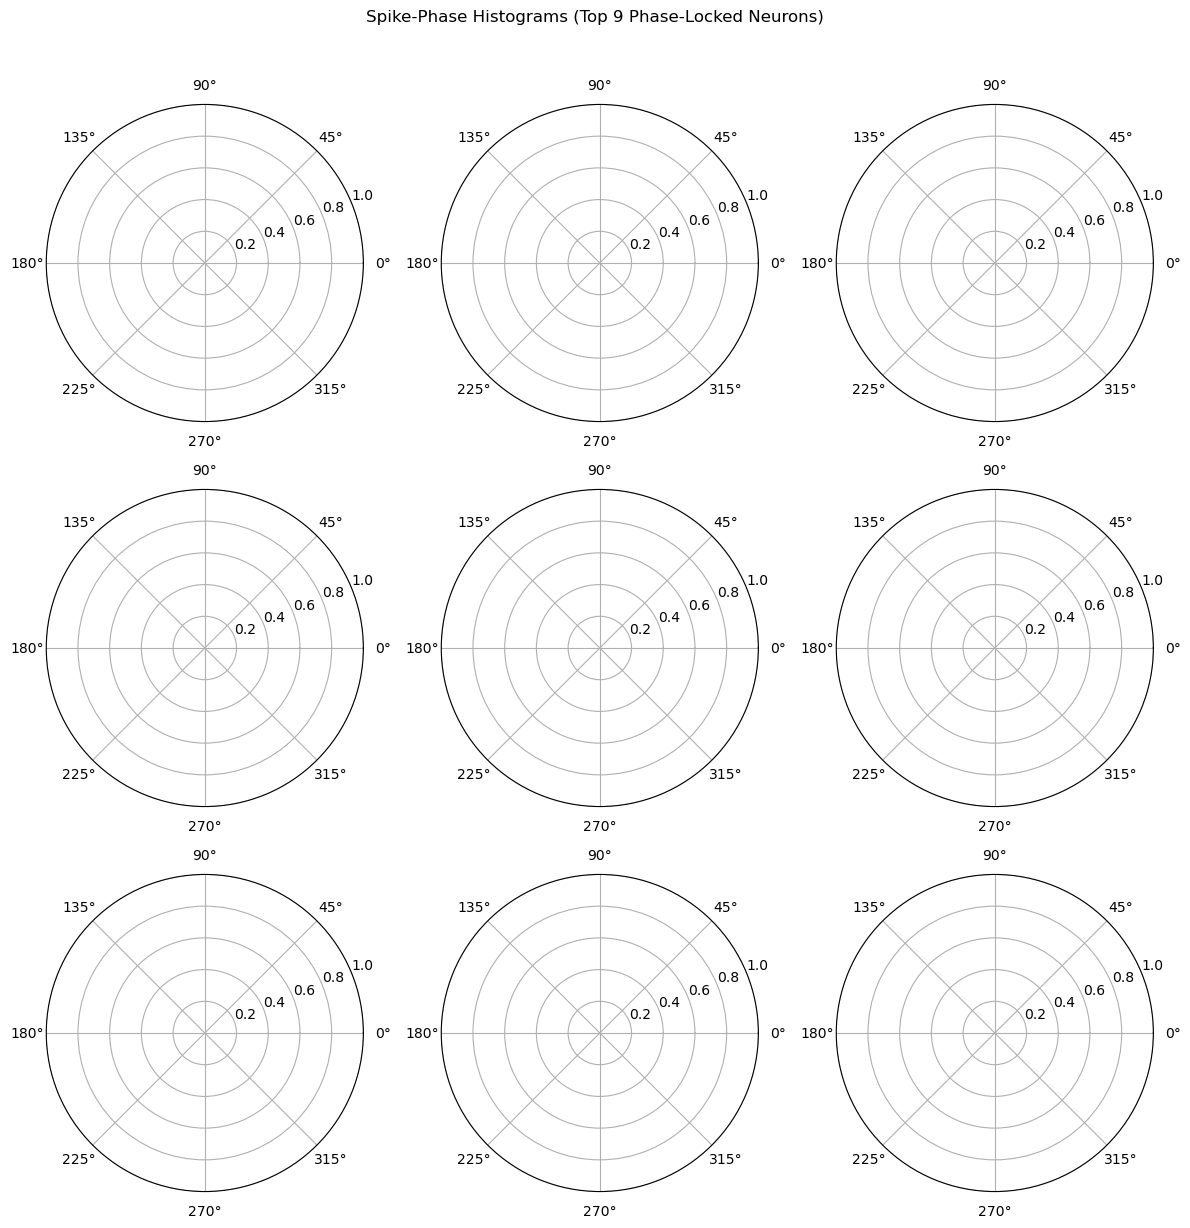

In [10]:
# Find most phase-locked neurons
top_mrl_indices = np.argsort(empirical_mrl)[::-1][:9]  # Top 9 by MRL
top_mrl_indices = top_mrl_indices[~np.isnan(empirical_mrl[top_mrl_indices])]

fig, axes = plt.subplots(3, 3, figsize=(12, 12), subplot_kw={"projection": "polar"})
axes = axes.flatten()

for i, neuron_idx in enumerate(top_mrl_indices):
    ax = axes[i]

    spike_times_n = get_spike_times_from_binned(spikes_subset, t_rel, neuron_idx)

    # Compute phase histogram
    hist, bin_centers = compute_phase_histogram(
        spike_times=spike_times_n,
        inferred_phase=np.array(inferred_phase),
        time_axis=t_rel,
        mask=theta_on_mask,
        n_bins=36,
    )

    # Plot as polar histogram
    width = 2 * np.pi / 36
    bars = ax.bar(bin_centers, hist, width=width, alpha=0.7)

    # Color by height
    colors = plt.cm.viridis(hist / np.max(hist) if np.max(hist) > 0 else hist)
    for bar, color in zip(bars, colors):
        bar.set_facecolor(color)

    # Mark preferred phase
    pref_phase = empirical_preferred_phases[neuron_idx]
    mrl = empirical_mrl[neuron_idx]
    p_val = empirical_p_values[neuron_idx]

    ax.axvline(pref_phase, color="red", linewidth=2, linestyle="--")
    ax.set_title(f"Neuron {neuron_idx}\nMRL={mrl:.3f}, p={p_val:.1e}")
    ax.set_rticks([])

plt.suptitle("Spike-Phase Histograms (Top 9 Phase-Locked Neurons)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("ca1_phase_histograms_top9.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Compare Phase-Locking: Theta-On vs Theta-Off

In [11]:
# Compare phase-locking during theta-on vs overall
print("Comparing phase-locking in different conditions...")

# Theta-off mask
theta_off_mask = ~theta_on_mask

# Compute MRL for each condition
mrl_theta_on = []
mrl_theta_off = []

for n in range(n_neurons):
    spike_times_n = get_spike_times_from_binned(spikes_subset, t_rel, n)

    if len(spike_times_n) < 10:
        mrl_theta_on.append(np.nan)
        mrl_theta_off.append(np.nan)
        continue

    # Theta-on
    _, mrl_on, _ = compute_preferred_phase(
        spike_times=spike_times_n,
        inferred_phase=np.array(inferred_phase),
        time_axis=t_rel,
        mask=theta_on_mask,
    )
    mrl_theta_on.append(mrl_on)

    # Theta-off
    _, mrl_off, _ = compute_preferred_phase(
        spike_times=spike_times_n,
        inferred_phase=np.array(inferred_phase),
        time_axis=t_rel,
        mask=theta_off_mask,
    )
    mrl_theta_off.append(mrl_off)

mrl_theta_on = np.array(mrl_theta_on)
mrl_theta_off = np.array(mrl_theta_off)

Comparing phase-locking in different conditions...


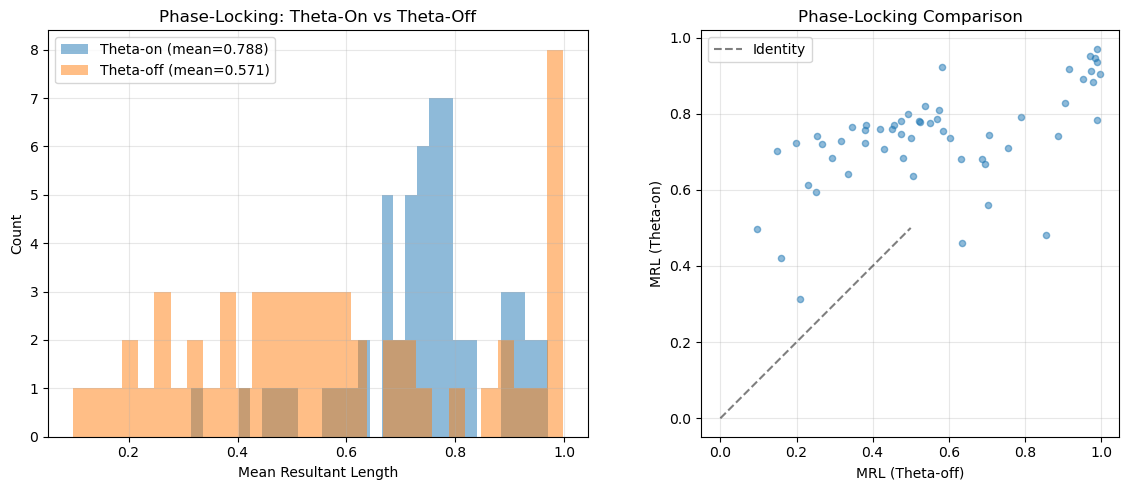


Phase-locking comparison:
  Mean MRL (theta-on): 0.788
  Mean MRL (theta-off): 0.571
  Ratio: 1.38x
  Wilcoxon test p-value: 7.82e-06


In [12]:
# Compare MRL distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograms
ax = axes[0]
valid = ~np.isnan(mrl_theta_on) & ~np.isnan(mrl_theta_off)
ax.hist(mrl_theta_on[valid], bins=30, alpha=0.5, label=f"Theta-on (mean={np.nanmean(mrl_theta_on):.3f})")
ax.hist(mrl_theta_off[valid], bins=30, alpha=0.5, label=f"Theta-off (mean={np.nanmean(mrl_theta_off):.3f})")
ax.set_xlabel("Mean Resultant Length")
ax.set_ylabel("Count")
ax.set_title("Phase-Locking: Theta-On vs Theta-Off")
ax.legend()
ax.grid(True, alpha=0.3)

# Scatter comparison
ax = axes[1]
ax.scatter(mrl_theta_off[valid], mrl_theta_on[valid], alpha=0.5, s=20)
ax.plot([0, 0.5], [0, 0.5], "k--", alpha=0.5, label="Identity")
ax.set_xlabel("MRL (Theta-off)")
ax.set_ylabel("MRL (Theta-on)")
ax.set_title("Phase-Locking Comparison")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("ca1_phase_locking_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Statistics
print(f"\nPhase-locking comparison:")
print(f"  Mean MRL (theta-on): {np.nanmean(mrl_theta_on):.3f}")
print(f"  Mean MRL (theta-off): {np.nanmean(mrl_theta_off):.3f}")
print(f"  Ratio: {np.nanmean(mrl_theta_on) / np.nanmean(mrl_theta_off):.2f}x")

# Paired test
from scipy.stats import wilcoxon
valid_paired = valid & (mrl_theta_on > 0) & (mrl_theta_off > 0)
if np.sum(valid_paired) > 10:
    stat, p_wilcoxon = wilcoxon(mrl_theta_on[valid_paired], mrl_theta_off[valid_paired])
    print(f"  Wilcoxon test p-value: {p_wilcoxon:.2e}")

## 8. Population Phase-Locking Visualization

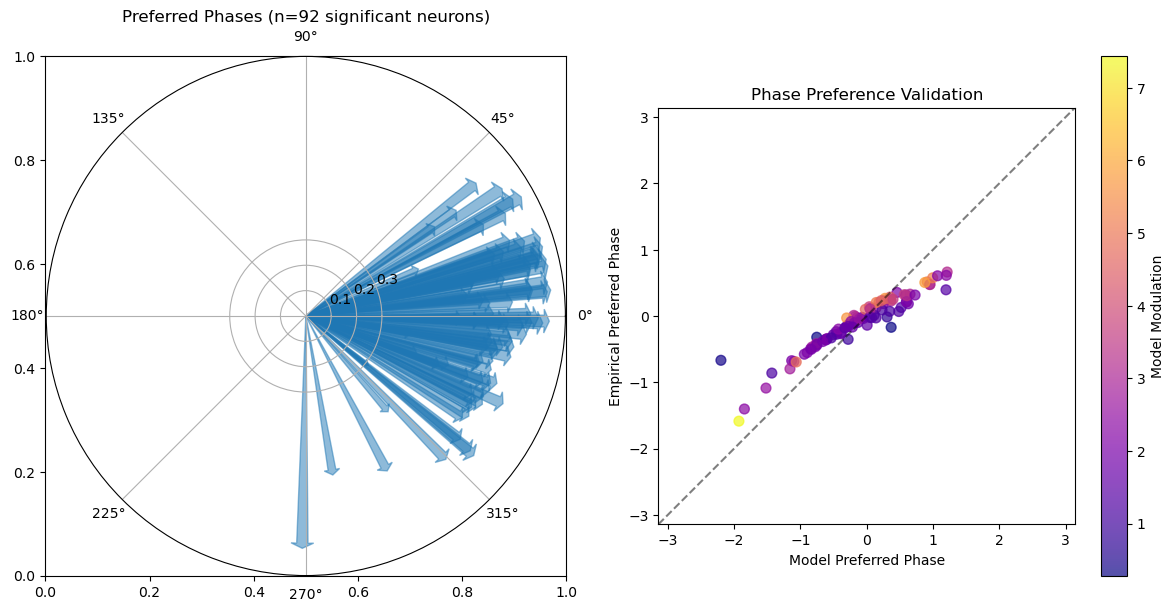

In [13]:
# Create population polar plot showing all neurons
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Polar plot of preferred phases (significant neurons)
ax = plt.subplot(1, 2, 1, projection="polar")
sig_mask = valid_mask & (empirical_p_values < 0.05)

# Plot each neuron as a vector from origin
for n in np.where(sig_mask)[0]:
    phase = empirical_preferred_phases[n]
    mrl = empirical_mrl[n]
    ax.arrow(phase, 0, 0, mrl, alpha=0.5, width=0.05, length_includes_head=True,
             head_width=0.1, head_length=0.02, fc="C0", ec="C0")

ax.set_title(f"Preferred Phases (n={np.sum(sig_mask)} significant neurons)")
ax.set_rticks([0.1, 0.2, 0.3])

# Distribution of phase preferences vs model weights
ax = axes[1]
ax.scatter(
    model_preferred_phases[sig_mask],
    empirical_preferred_phases[sig_mask],
    c=model_modulation_strength[sig_mask],
    cmap="plasma",
    s=50,
    alpha=0.7,
)
ax.plot([-np.pi, np.pi], [-np.pi, np.pi], "k--", alpha=0.5)
ax.set_xlabel("Model Preferred Phase")
ax.set_ylabel("Empirical Preferred Phase")
ax.set_title("Phase Preference Validation")
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, label="Model Modulation")

plt.tight_layout()
plt.savefig("ca1_population_phase_locking.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Phase-Dependent Firing Rate Modulation

In [14]:
# Compute firing rate as function of theta phase (population average)
n_phase_bins = 36
phase_bin_edges = np.linspace(-np.pi, np.pi, n_phase_bins + 1)
phase_bin_centers = (phase_bin_edges[:-1] + phase_bin_edges[1:]) / 2

# Compute population firing rate in each phase bin during theta-on
pop_rate_by_phase = np.zeros(n_phase_bins)
time_in_phase = np.zeros(n_phase_bins)

for i in range(n_phase_bins):
    phase_mask = (
        (inferred_phase >= phase_bin_edges[i]) &
        (inferred_phase < phase_bin_edges[i + 1]) &
        theta_on_mask
    )
    if np.sum(phase_mask) > 0:
        pop_rate_by_phase[i] = np.sum(spikes_subset[phase_mask, :]) / (np.sum(phase_mask) * dt)
        time_in_phase[i] = np.sum(phase_mask) * dt

# Normalize by time in each phase bin
pop_rate_by_phase_normalized = pop_rate_by_phase / n_neurons

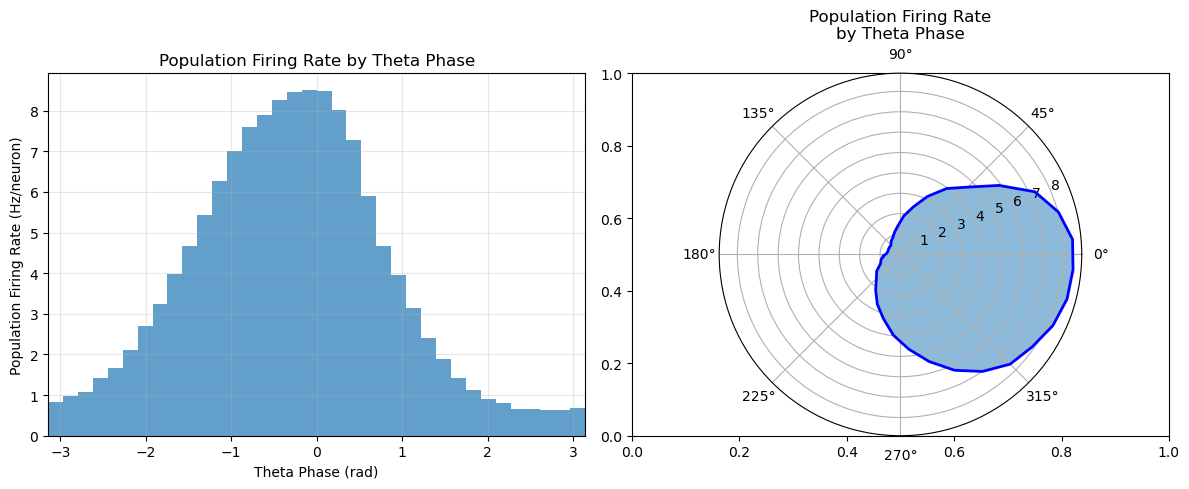

Population firing rate modulation depth: 2.09


In [15]:
# Plot population firing rate modulation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
ax = axes[0]
ax.bar(phase_bin_centers, pop_rate_by_phase_normalized, width=2*np.pi/n_phase_bins, alpha=0.7)
ax.set_xlabel("Theta Phase (rad)")
ax.set_ylabel("Population Firing Rate (Hz/neuron)")
ax.set_title("Population Firing Rate by Theta Phase")
ax.set_xlim(-np.pi, np.pi)
ax.grid(True, alpha=0.3)

# Polar plot
ax = plt.subplot(1, 2, 2, projection="polar")
# Extend data for wrapping
phases_extended = np.concatenate([phase_bin_centers, [phase_bin_centers[0]]])
rates_extended = np.concatenate([pop_rate_by_phase_normalized, [pop_rate_by_phase_normalized[0]]])
ax.fill(phases_extended, rates_extended, alpha=0.5)
ax.plot(phases_extended, rates_extended, "b-", linewidth=2)
ax.set_title("Population Firing Rate\nby Theta Phase")

plt.tight_layout()
plt.savefig("ca1_population_rate_by_phase.png", dpi=150, bbox_inches="tight")
plt.show()

# Modulation depth
mod_depth = (np.max(pop_rate_by_phase_normalized) - np.min(pop_rate_by_phase_normalized)) / np.mean(pop_rate_by_phase_normalized)
print(f"Population firing rate modulation depth: {mod_depth:.2f}")

## 10. Summary

In [16]:
print("=" * 60)
print("Phase-Locking Analysis Summary")
print("=" * 60)

print(f"\nNeurons analyzed: {n_neurons}")
print(f"  Valid (>10 spikes): {n_valid}")
print(f"  Significantly phase-locked (p<0.05): {n_significant} ({100*n_significant/n_valid:.1f}%)")

print(f"\nPhase-locking strength:")
print(f"  Mean MRL: {np.nanmean(empirical_mrl):.3f}")
print(f"  Max MRL: {np.nanmax(empirical_mrl):.3f}")

print(f"\nTheta-on vs Theta-off:")
print(f"  Mean MRL (theta-on): {np.nanmean(mrl_theta_on):.3f}")
print(f"  Mean MRL (theta-off): {np.nanmean(mrl_theta_off):.3f}")

print(f"\nModel validation:")
print(f"  Circular correlation (model vs empirical phases): {circ_corr:.3f}")
print(f"  Correlation (model weights vs empirical MRL): {mod_mrl_corr:.3f}")

print(f"\nPopulation modulation:")
print(f"  Firing rate modulation depth: {mod_depth:.2f}")

print("=" * 60)

Phase-Locking Analysis Summary

Neurons analyzed: 107
  Valid (>10 spikes): 92
  Significantly phase-locked (p<0.05): 92 (100.0%)

Phase-locking strength:
  Mean MRL: 0.788
  Max MRL: 0.975

Theta-on vs Theta-off:
  Mean MRL (theta-on): 0.788
  Mean MRL (theta-off): 0.571

Model validation:
  Circular correlation (model vs empirical phases): 0.958
  Correlation (model weights vs empirical MRL): 0.765

Population modulation:
  Firing rate modulation depth: 2.09


## Key Findings

1. **Phase-locking is present**: A significant fraction of CA1 neurons show
   statistically significant phase-locking to the inferred theta oscillation.

2. **Theta-on vs Theta-off**: Phase-locking is stronger during inferred theta-on
   periods compared to theta-off periods, validating the state segmentation.

3. **Model consistency**: The empirical preferred phases correlate with the
   model-learned spike weights, indicating the model captures genuine
   phase relationships.

4. **Population rhythmicity**: The population firing rate shows modulation
   by theta phase, consistent with theta-coordinated hippocampal activity.

## Next Steps

Potential extensions:

1. **Three-state model**: Try theta-off / theta-on / ambiguous states
2. **Two-oscillator model**: Add a second oscillator for assembly dynamics
3. **Place-cell analysis**: Correlate phase preferences with spatial coding
4. **Cross-validation**: Fit on one time window, validate on another